# **International Arrivals to Vietnam Forecasting**
---
## **1. Problem Introduction**

### **a. Definition**
**Objective:** Predict the total number of international tourist arrivals to Vietnam on a monthly basis from January 2008 to February 2026

**Purpose:**

* plan tourism infrastructure
* forecast revenue for the service sector
* allocate communication and marketing resources
* identify recovery trends after major events (COVID-19)

**Technical representation:** Time Series Forecasting Problem

**Goal:** Model the relationship between the target variable (`international_arrivals_total`) and the explanatory variables (`date_month_start`, `positive_event_flag` and `negative_event_flag` in `exogenous_arrivals.csv`)

### **b. Methodology:** **Linear Regression** for time series forecasting
**First stage:** Linear Regression with **Gradient Descent** (univariate baseline)

**Next stage:** apply **Normal Equation** (multivariate model)

**Purpose:** compare optimization methods, extend the model with more explanatory variables while maintaining computational efficiency

### **c. Dataset**

`endogenous_arrivals.csv`: monthly dates, total arrivals

`exogenous_arrivals.csv`: binary flags for positive, negative events

`combined_arrivals.csv`: merged dataset, utilized in the final Normal Equationn model

---
## **2. Code Implementation**

### **a. Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **b. Preprocessing data**

In [9]:
file_endo = 'endogenous_arrivals.csv'
df_endo = pd.read_csv(file_endo)
df_endo.head()

,date_month_start,international_arrivals_total
0,2008-01-01,399556
1,2008-02-01,411032
2,2008-03-01,414332
3,2008-04-01,395900
4,2008-05-01,366387


In [3]:
file_exo = 'exogenous_arrivals.csv'
df_exo = pd.read_csv(file_exo)

#Merge data base on mutual 'date_month_start' column
df_merged = pd.merge(df_endo, df_exo[['date_month_start', 'positive_event_flag', 'negative_event_flag']], on='date_month_start', how = 'left')

#Save as new csv data file or replace exogenous file
df_merged.to_csv('combined_arrivals.csv', index=False)

df_merged.head()

,date_month_start,international_arrivals_total,positive_event_flag,negative_event_flag
0,2008-01-01,399556,1,0
1,2008-02-01,411032,1,0
2,2008-03-01,414332,0,1
3,2008-04-01,395900,1,0
4,2008-05-01,366387,1,0


#### **b.1. Gradient Descent**

In [4]:
#1. Prepare data for Gradient Descent (endogenous)
    #add column replace date_month_start into t = 0, 1, 2... (here: X = t)
X_endo = np.arange(len(df_endo))
Y_endo = df_endo['international_arrivals_total']
    #normalization
X_endo = np.array((X_endo - X_endo.mean()) / X_endo.std())
Y_endo = np.array((Y_endo - Y_endo.mean())/ Y_endo.std())
    #convert X_endo into 2D matrix, add column x0 = 1
X_endo = np.c_[np.ones(X_endo.shape), X_endo]

#### **b.2. Normal Equation**

In [5]:
#2. Prepare data for Normal Equation (combine)
X_comb = np.arange(len(df_merged))
Y_comb = df_merged['international_arrivals_total']
    #Create X_comb matrix: t, negative, positive
X_comb = pd.DataFrame({
    't': X_comb,
    'positive_event_flag': df_merged['positive_event_flag'],
    'negative_event_flag': df_merged['negative_event_flag']
})
    #normalization
X_comb = np.array((X_comb - X_comb.mean()) / X_comb.std())
Y_comb = np.array((Y_comb - Y_comb.mean())/ Y_comb.std())
    #add column x0 = 1
X_comb = np.c_[np.ones(X_comb.shape[0]), X_comb]

### **c. Cost Function Over Iteration**

#### **c.1. Gradient Descent**

In [ ]:
def init(dim):
    return np.random.rand(dim)
theta = init(X_endo.shape[1])

def predict_Y(theta, X):
    return np.dot(X, theta)

def get_cost(Y, Y_hat):
    m = len(Y)
    cost = (1/(2*m)) * np.sum((Y_hat - Y) ** 2)
    return cost

#Gradient Descent
def gradient_descent(X, Y, theta, alpha, iterations):
    m = len(Y)
    cost_history = []

    for i in range (iterations):
        Y_hat = predict_Y(theta, X)
        gradient = (1/m) * np.dot(X.T, (Y_hat - Y))
        theta = theta - alpha * gradient
        new_Y_hat = predict_Y(theta, X)
        cost = get_cost(Y, new_Y_hat)
        cost_history.append(cost)
    return theta, cost_history

**Run Gradient Descent**

In [11]:
alpha = 0.01
iterations = 1000

#Gradient Descent
print("\n---Gradient Descent---")
optimized_theta, cost_history = gradient_descent(X_endo, Y_endo, theta, alpha, iterations)
print("Optimized Theta:", optimized_theta)


---Gradient Descent---
Optimized Theta: [3.30547885e-06 5.01407581e-01]


**Plot Cost Function** 

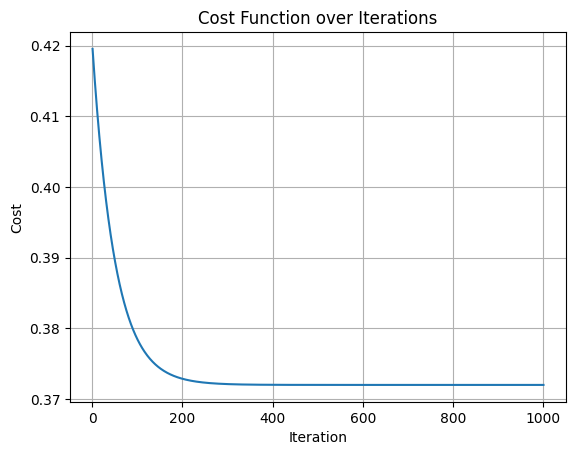

In [ ]:
#Standardize data before plot
plt.plot(range(1, iterations + 1), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations")
plt.grid(True)
plt.show()

**Predict - Actual**

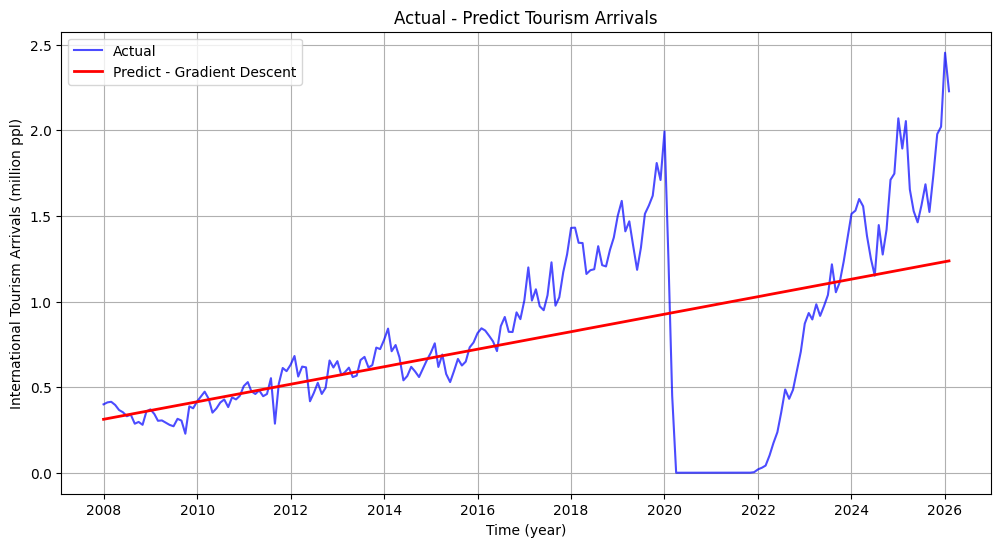

In [ ]:
#Predict - Actual graph
    #standardize data
Y_pred_optimize = predict_Y(optimized_theta, X_endo)
Y_orig = df_endo['international_arrivals_total']
Y_mean_orig = Y_orig.mean()
Y_std_orig = Y_orig.std()

Y_actual = Y_orig / 1000000
Y_pred_actual = ((Y_pred_optimize * Y_std_orig) + Y_mean_orig) / 1000000

dates = pd.to_datetime(df_endo['date_month_start'])

plt.figure(figsize=(12, 6))
    #actual line (blue)
plt.plot(dates, Y_actual, label='Actual', color = 'blue', alpha=0.7)
    #predicted line (grad descent) (red)
plt.plot(dates, Y_pred_actual, label='Predict - Gradient Descent', color='red', linewidth=2)

plt.title("Actual - Predict Tourism Arrivals")
plt.xlabel("Time (year)")
plt.ylabel("International Tourism Arrivals (million ppl)")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

**Evaluate Model (Gradient Descent)**

In [27]:
def evaluate_model(Y, Y_hat):
    mae = np.mean(np.abs(Y - Y_hat))
    mse = np.mean((Y - Y_hat) ** 2)

    ss_total = np.sum((Y - np.mean(Y)) ** 2)
    ss_res = np.sum((Y - Y_hat) ** 2)
    r2 = 1 - (ss_res / ss_total)

    print(f"Mean Absolute Error (MAE):  {mae:.4f}")
    print(f"Mean Square Error (MSE):    {mse:.4f}")
    print(f"R Square (R^2):             {r2:.4f}")

    return mae, mse, r2

In [28]:
print("\nEvaluate Model using Gradient Descent:")
evaluate_model(Y_endo, Y_pred_optimize)


Evaluate Model using Gradient Descent:
Mean Absolute Error (MAE):  0.5886
Mean Square Error (MSE):    0.7440
R Square (R^2):             0.2526


(np.float64(0.5885935454672603),
 np.float64(0.7439902090968795),
 np.float64(0.2525812645939184))

#### **c.2. Normal Equation**

In [24]:
def normal_equation(X, Y):
    #theta = (X^TX)^-1 X^T Y
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    XTY = np.dot(X.T, Y)
    theta = np.dot(XTX_inv, XTY)
    return theta

**Run Normal Equation**

In [25]:
#Normal Equation
print("\n---Normal Equation---")
normalized_theta = normal_equation(X_comb, Y_comb)
print("Normalized Theta:", normalized_theta)


---Normal Equation---
Normalized Theta: [ 4.13670038e-17  4.63868308e-01  6.01655559e-02 -2.10782842e-01]


**Evaluate Model (Normal Equation)**

In [29]:
Y_pred_normal = predict_Y(normalized_theta, X_comb)
print("\nEvaluate Model using Normal Equation:")
evaluate_model(Y_comb, Y_pred_normal)


Evaluate Model using Normal Equation:
Mean Absolute Error (MAE):  0.6002
Mean Square Error (MSE):    0.6860
R Square (R^2):             0.3108


(np.float64(0.6002232019363719),
 np.float64(0.6860418958796844),
 np.float64(0.31079662072916503))